Goal: Predict whether a flight will be delayed more than 15 minutes and arrival delay before departure.  
Dataset Choice: Selected an imbalanced dataset to reflect real-world scenarios, where most flights are on time.  
Purpose: Use this challenge to improve modeling skills and explore techniques for enhancing model performance.  
Models: Logistic Regression, Random Forest, XGBoost  


In [1]:

import pandas as pd
import numpy as np

import sklearn # Machine Learning 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost 
from xgboost import XGBClassifier


from sklearn.compose import ColumnTransformer # Data Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler,LabelEncoder,TargetEncoder
from sklearn.pipeline import Pipeline


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score,precision_score
from sklearn.metrics import ConfusionMatrixDisplay


I used a weather 'Meteo' API to generate a CSV file.  

temperature_2m_max  

temperature_2m_min  

precipitation_sum  


In [ ]:
# import requests
# import time

# airports = pd.read_csv('datasets/csv_files/airports.csv')  
# all_weather = []


# for idx, row in airports.iterrows():
#     lat = row['LATITUDE']
#     lon = row['LONGITUDE']
#     airport_name = row['AIRPORT']
#     iata = row['IATA_CODE']
    
#     # Skip if coordinates are missing
#     if pd.isnull(lat) or pd.isnull(lon):
#         print(f"Skipping {airport_name} ({iata}) - missing coordinates")
#         continue
    
#     # Build API URL (example: Jan 2015)
#     url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date=2015-01-01&end_date=2015-12-31&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&timezone=auto"
    
#     try:
#         r = requests.get(url, timeout=10).json()
#     except Exception as e:
#         print(f"Error fetching {airport_name} ({iata}): {e}")
#         continue
    
#     # Check if 'daily' exists in response
#     if 'daily' in r:
#         df = pd.DataFrame(r['daily'])
#         df['AIRPORT'] = airport_name
#         df['IATA_CODE'] = iata
#         all_weather.append(df)
#         print(f"Fetched data for {airport_name} ({iata})")
#     else:
#         print(f"No daily data for {airport_name} ({iata})")
    
    
# if all_weather:
#     weather_data = pd.concat(all_weather, ignore_index=True)
#     weather_data.to_csv('airport_weather.csv', index=False)
# else:
#     print("⚠️ No weather data was fetched")

In [3]:
weather = pd.read_csv('airport_weather.csv') 
flights=pd.read_csv("datasets/csv_files/flights.csv")
airports = pd.read_csv("datasets/csv_files/airports.csv")

C:\Users\DELL\AppData\Local\Temp\ipykernel_27872\1339565774.py:2: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  flights=pd.read_csv("datasets/csv_files/flights.csv")


In [5]:
info_table=pd.DataFrame({
    'Column':flights.columns,
    'Missing Values':flights.isnull().sum().values,
    'Filling Factor (%)' : (flights.shape[0] - flights.isnull().sum().values) / flights.shape[0] * 100,
    'Dtype':flights.dtypes.values,
    
})
info_table=info_table.sort_values(by='Filling Factor (%)',ascending=True)
info_table

,Column,Missing Values,Filling Factor (%),Dtype
25,CANCELLATION_REASON,5729195,1.544643,str
27,SECURITY_DELAY,4755640,18.275040,float64
30,WEATHER_DELAY,4755640,18.275040,float64
29,LATE_AIRCRAFT_DELAY,4755640,18.275040,float64
28,AIRLINE_DELAY,4755640,18.275040,float64
26,AIR_SYSTEM_DELAY,4755640,18.275040,float64
15,ELAPSED_TIME,105071,98.194371,float64
16,AIR_TIME,105071,98.194371,float64
22,ARRIVAL_DELAY,105071,98.194371,float64
21,ARRIVAL_TIME,92513,98.410178,float64


1 → flight delayed ≥ 15 minutes / delayed  

0 → flight delayed < 15 minutes / on-time

In [ ]:
flights["DELAY_15"] = (flights["ARRIVAL_DELAY"] >= 15).astype(int) # if flights are delayed more than 15 min they will be delayed

flights.csv  has  scheduled, actual, and delay columns, goal is predicting arrival delay before departure, so I keep scheduled information.  

Delay Informations  basically explain the answer. So removed them.

In [ ]:
flights.columns

In [7]:
col_remove=["CANCELLED","CANCELLATION_REASON","DIVERTED","TAIL_NUMBER"] 
delay_col=[ 'ARRIVAL_DELAY','AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY','LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'] # delay causing info
arrival_actual=['ELAPSED_TIME','WHEELS_ON', 'TAXI_IN','ARRIVAL_TIME','AIR_TIME',] 

In [8]:
flights=flights.drop(columns=col_remove)
flights=flights.drop(columns=delay_col)
flights=flights.drop(columns=arrival_actual)

In [9]:
info_table=pd.DataFrame({
    'Column':weather.columns,
    'Missing Values':weather.isnull().sum().values,
    'Filling Factor (%)' : (weather.shape[0] - weather.isnull().sum().values) / weather.shape[0] * 100,
    'Dtype':weather.dtypes.values,
    
})
info_table=info_table.sort_values(by='Filling Factor (%)',ascending=True)
info_table

,Column,Missing Values,Filling Factor (%),Dtype
0,time,0,100.0,str
1,temperature_2m_max,0,100.0,float64
2,temperature_2m_min,0,100.0,float64
3,precipitation_sum,0,100.0,float64
4,AIRPORT,0,100.0,str
5,IATA_CODE,0,100.0,str


In [10]:
flights["DATE"] = pd.to_datetime(flights[["YEAR", "MONTH", "DAY"]])
flights['ORIGIN_AIRPORT'] = flights['ORIGIN_AIRPORT'].astype(str)
flights['DESTINATION_AIRPORT'] = flights['DESTINATION_AIRPORT'].astype(str)
# Weather CSV
weather['DATE'] = pd.to_datetime(weather['time'])
weather['IATA_CODE'] = weather['IATA_CODE'].astype(str)


# Merge Origin Airport Weather

weather_origin = weather.rename(columns={
    'IATA_CODE': 'ORIGIN_AIRPORT',
    'temperature_2m_max': 'TEMP_MAX_ORIGIN',
    'temperature_2m_min': 'TEMP_MIN_ORIGIN',
    'precipitation_sum': 'PRECIP_ORIGIN'
})

merged = pd.merge(
    flights,
    weather_origin,
    on=['DATE', 'ORIGIN_AIRPORT'],
    how='left'
)




In [11]:
# Merge Destination Airport Weather

weather_dest = weather.rename(columns={
    'IATA_CODE': 'DESTINATION_AIRPORT',
    'temperature_2m_max': 'TEMP_MAX_DEST',
    'temperature_2m_min': 'TEMP_MIN_DEST',
    'precipitation_sum': 'PRECIP_DEST'
})

merged = pd.merge(
    merged,
    weather_dest,
    on=['DATE', 'DESTINATION_AIRPORT'],
    how='left'
)


In [12]:
col_remove=["AIRPORT_y","AIRPORT_x","time_y","time_x","DATE","YEAR"] 
merged=merged.drop(columns=col_remove)

In [13]:
print(merged.head())

   MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER ORIGIN_AIRPORT  \
0      1    1            4      AS             98            ANC   
1      1    1            4      AA           2336            LAX   
2      1    1            4      US            840            SFO   
3      1    1            4      AA            258            LAX   
4      1    1            4      AS            135            SEA   

  DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  DEPARTURE_TIME  DEPARTURE_DELAY  \
0                 SEA                    5          2354.0            -11.0   
1                 PBI                   10             2.0             -8.0   
2                 CLT                   20            18.0             -2.0   
3                 MIA                   20            15.0             -5.0   
4                 ANC                   25            24.0             -1.0   

   ...  SCHEDULED_TIME  DISTANCE  SCHEDULED_ARRIVAL  DELAY_15  \
0  ...           205.0      1448                430

In [14]:
info_table=pd.DataFrame({
    'Column':merged.columns,
    'Missing Values':merged.isnull().sum().values,
    'Filling Factor (%)' : (merged.shape[0] - merged.isnull().sum().values) / merged.shape[0] * 100,
    'Dtype':merged.dtypes.values,
    
})
info_table=info_table.sort_values(by='Filling Factor (%)',ascending=True)
info_table

,Column,Missing Values,Filling Factor (%),Dtype
20,TEMP_MIN_DEST,1352834,76.751751,float64
21,PRECIP_DEST,1352834,76.751751,float64
19,TEMP_MAX_DEST,1352834,76.751751,float64
16,TEMP_MAX_ORIGIN,1352818,76.752026,float64
17,TEMP_MIN_ORIGIN,1352818,76.752026,float64
18,PRECIP_ORIGIN,1352818,76.752026,float64
10,TAXI_OUT,89047,98.469741,float64
11,WHEELS_OFF,89047,98.469741,float64
8,DEPARTURE_TIME,86153,98.519474,float64
9,DEPARTURE_DELAY,86153,98.519474,float64


In [15]:
airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [ ]:
col_remove=["AIRPORT","COUNTRY","LATITUDE","LONGITUDE"]  # remove cols which are not used for model
airports=airports.drop(columns=col_remove)

In [17]:
merged=merged.merge(airports,left_on='ORIGIN_AIRPORT',right_on='IATA_CODE',how='left')

In [18]:
merged.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DELAY_15',
       'TEMP_MAX_ORIGIN', 'TEMP_MIN_ORIGIN', 'PRECIP_ORIGIN', 'TEMP_MAX_DEST',
       'TEMP_MIN_DEST', 'PRECIP_DEST', 'IATA_CODE', 'CITY', 'STATE'],
      dtype='str')

In [19]:
merged.drop_duplicates(inplace=True)
merged.shape

(5819079, 25)

In [20]:
info_table=pd.DataFrame({
    'Column':merged.columns,
    'Missing Values':merged.isnull().sum().values,
    'Filling Factor (%)' : (merged.shape[0] - merged.isnull().sum().values) / merged.shape[0] * 100,
    'Dtype':merged.dtypes.values,
    
})
info_table=info_table.sort_values(by='Filling Factor (%)',ascending=True)
info_table

,Column,Missing Values,Filling Factor (%),Dtype
20,TEMP_MIN_DEST,1352834,76.751751,float64
21,PRECIP_DEST,1352834,76.751751,float64
19,TEMP_MAX_DEST,1352834,76.751751,float64
16,TEMP_MAX_ORIGIN,1352818,76.752026,float64
17,TEMP_MIN_ORIGIN,1352818,76.752026,float64
18,PRECIP_ORIGIN,1352818,76.752026,float64
23,CITY,486165,91.645327,str
22,IATA_CODE,486165,91.645327,str
24,STATE,486165,91.645327,str
10,TAXI_OUT,89047,98.469741,float64


In [21]:
merged = merged.drop("IATA_CODE", axis=1)

I created a correlation matrix to understand relationships between variables in 'merged'  dataset before building a model

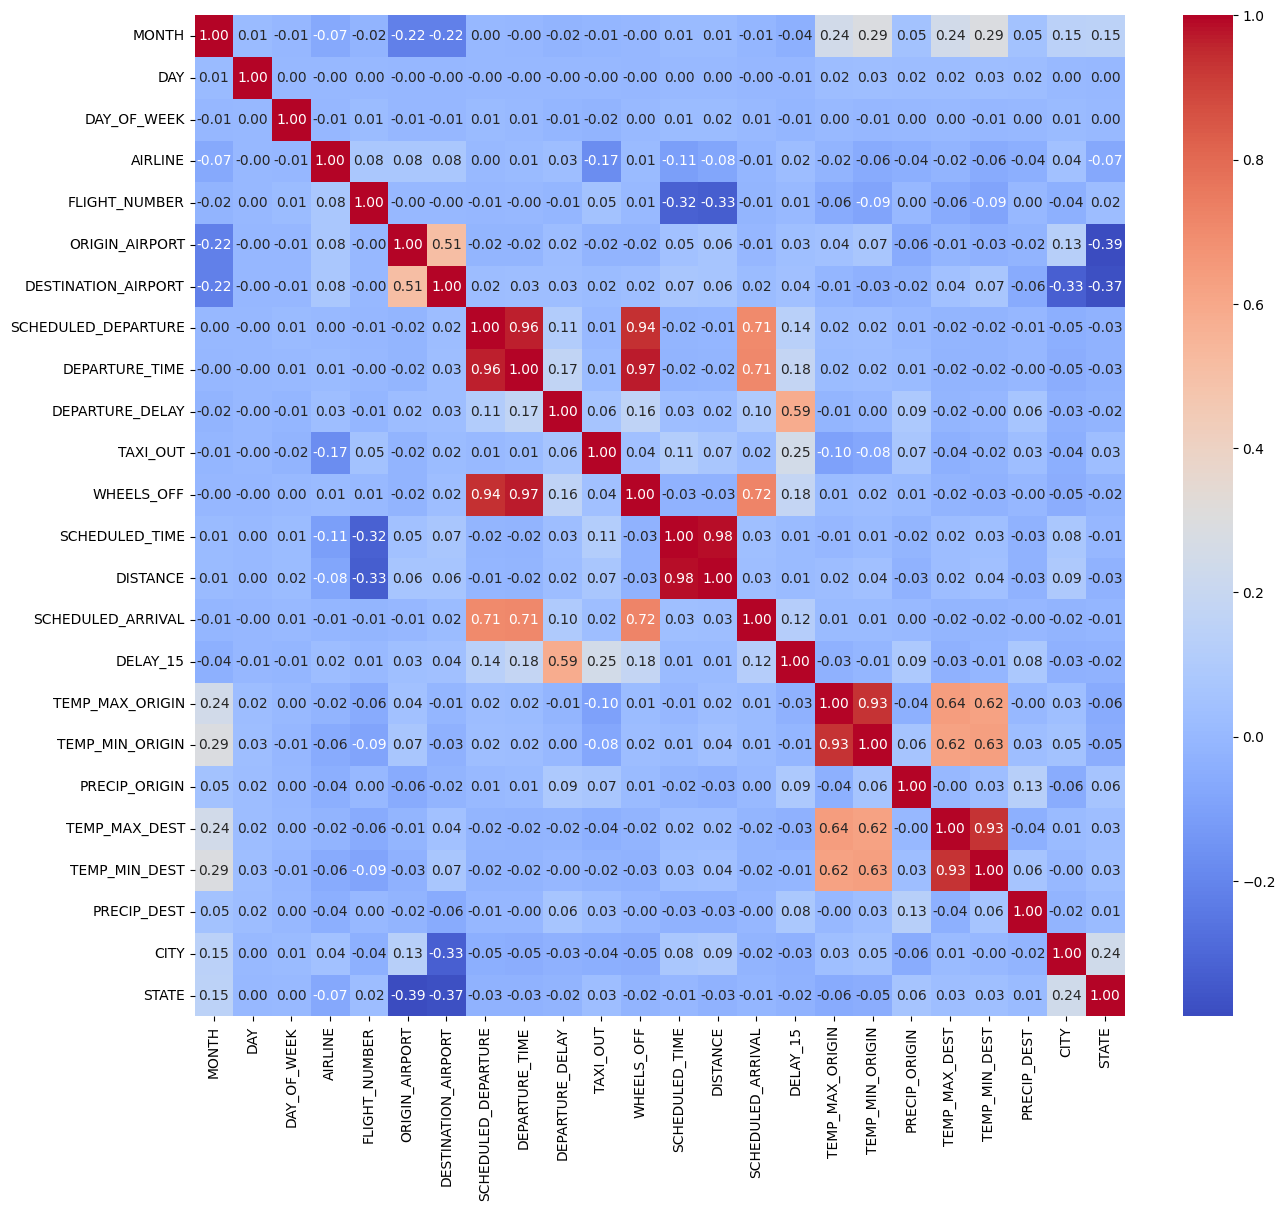

In [ ]:
merged_corr = merged.copy() # is used to avoid modifying the original  'merged' dataset by accident.
str_cols =["AIRLINE", "CITY", "STATE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]   # A correlation matrix only works with numeric data, because it calculates how numbers move together

for col in str_cols:
    merged_corr[col] = LabelEncoder().fit_transform(merged_corr[col])
numeric_cols = merged_corr.select_dtypes(include=["int64","float64"]).columns
corr_matrix = merged_corr[numeric_cols].corr()


plt.figure(figsize=(15,13))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

Departure_Delay is highly predictive of Arrival_Delay (~59% correlation). Including it improves post-departure predictions but cannot be used for pre-departure models.

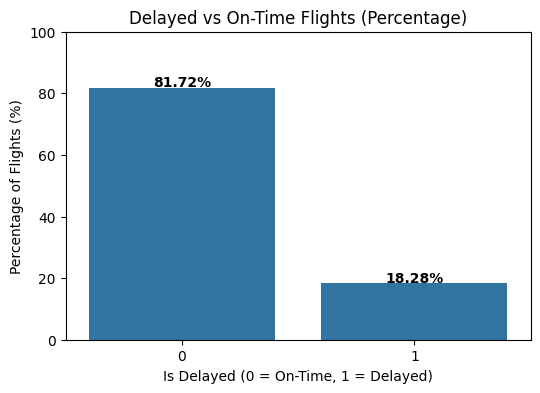

In [23]:
# Make a copy to avoid modifying the original dataset
merged_eda = merged.copy()

# Create a binary target: delayed if ARRIVAL_DELAY > 15 minutes
delay_counts = merged["DELAY_15"].value_counts(normalize=True) * 100

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=delay_counts.index, y=delay_counts.values)
plt.title("Delayed vs On-Time Flights (Percentage)")
plt.xlabel("Is Delayed (0 = On-Time, 1 = Delayed)")
plt.ylabel("Percentage of Flights (%)")

# Annotate percentages on top of bars
for i, v in enumerate(delay_counts.values):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontweight='bold')

plt.ylim(0, 100)
plt.show()

1. Dataset is imbalanced:  

82% on-time (On_Time = 0)  

18% delayed (Is_Delayed = 1)  


2. Algorithm choice  

Tree-based models (Random Forest, XGBoost) handle imbalance better with parameters like scale_pos_weight or class_weight.  

Linear models (Logistic Regression) often need resampling or class weighting to perform well.  


3.Accuracy alone is misleading  

Precision, Recall, F1-score  

ROC-AUC (area under the curve)

I have created pre-cleaned csv 

In [25]:
merged.to_csv("final.csv", index=False)


Data preparition for modeling

In [26]:
df=pd.read_csv('final.csv')

C:\Users\DELL\AppData\Local\Temp\ipykernel_27872\3403817249.py:1: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT, 2: CITY, 3: STATE) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('final.csv')


In [27]:
info_table=pd.DataFrame({
    'Column':df.columns,
    'Missing Values':df.isnull().sum().values,
    'Filling Factor (%)' : (df.shape[0] - df.isnull().sum().values) / df.shape[0] * 100,
    'Dtype':df.dtypes.values,
    
})
info_table=info_table.sort_values(by='Filling Factor (%)',ascending=True)
info_table

,Column,Missing Values,Filling Factor (%),Dtype
20,TEMP_MIN_DEST,1352834,76.751751,float64
21,PRECIP_DEST,1352834,76.751751,float64
19,TEMP_MAX_DEST,1352834,76.751751,float64
16,TEMP_MAX_ORIGIN,1352818,76.752026,float64
17,TEMP_MIN_ORIGIN,1352818,76.752026,float64
18,PRECIP_ORIGIN,1352818,76.752026,float64
23,STATE,486165,91.645327,str
22,CITY,486165,91.645327,str
10,TAXI_OUT,89047,98.469741,float64
11,WHEELS_OFF,89047,98.469741,float64


In [28]:
categorical_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
for col in categorical_cols:
    df[col] = df[col].astype("category")

MODEL 

In [ ]:
df_copy = df.copy() # Make a copy to avoid modifying the original dataset

In [60]:
df_copy.head()

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,...,SCHEDULED_ARRIVAL,DELAY_15,TEMP_MAX_ORIGIN,TEMP_MIN_ORIGIN,PRECIP_ORIGIN,TEMP_MAX_DEST,TEMP_MIN_DEST,PRECIP_DEST,CITY,STATE
0,1,1,4,AS,98,ANC,SEA,5,2354.0,-11.0,...,430,0,0.6,-4.6,0.0,3.7,-3.4,0.0,Anchorage,AK
1,1,1,4,AA,2336,LAX,PBI,10,2.0,-8.0,...,750,0,13.0,0.7,0.0,NaN,NaN,NaN,Los Angeles,CA
2,1,1,4,US,840,SFO,CLT,20,18.0,-2.0,...,806,0,11.3,3.5,0.0,10.5,-1.7,0.0,San Francisco,CA
3,1,1,4,AA,258,LAX,MIA,20,15.0,-5.0,...,805,0,13.0,0.7,0.0,25.8,20.3,1.7,Los Angeles,CA
4,1,1,4,AS,135,SEA,ANC,25,24.0,-1.0,...,320,0,3.7,-3.4,0.0,0.6,-4.6,0.0,Seattle,WA


In [62]:
df_copy.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DELAY_15',
       'TEMP_MAX_ORIGIN', 'TEMP_MIN_ORIGIN', 'PRECIP_ORIGIN', 'TEMP_MAX_DEST',
       'TEMP_MIN_DEST', 'PRECIP_DEST', 'CITY', 'STATE'],
      dtype='str')

In [ ]:
# Keep only rows where STATE and CITY are not missing , filling factor is 92%
df_copy = df_copy[df_copy['STATE'].notna() & df_copy['CITY'].notna()]


In [ ]:
#For all numeric columns, we replace missing values with the column median so that our model doesn’t break due to missing data.
numeric_cols = df_copy.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    median_val = df_copy[col].median()
    df_copy[col] = df_copy[col].fillna(median_val)

In [ ]:
# I reduce the size of numeric columns to make the dataset smaller and faster to process
float_cols = df_copy.select_dtypes(include=['float64']).columns
df_copy[float_cols] = df_copy[float_cols].astype('float32')
int_cols = df_copy.select_dtypes(include=['int64']).columns
df_copy[int_cols] = df_copy[int_cols].astype('int32')

In [68]:
info_table=pd.DataFrame({
    'Column':df_copy.columns,
    'Missing Values':df_copy.isnull().sum().values,
    'Filling Factor (%)' : (df_copy.shape[0] - df_copy.isnull().sum().values) / df_copy.shape[0] * 100,
    'Dtype':df_copy.dtypes.values,
    
})
info_table=info_table.sort_values(by='Filling Factor (%)',ascending=True)
info_table

,Column,Missing Values,Filling Factor (%),Dtype
0,MONTH,0,100.0,int32
1,DAY,0,100.0,int32
2,DAY_OF_WEEK,0,100.0,int32
3,AIRLINE,0,100.0,str
4,FLIGHT_NUMBER,0,100.0,int32
5,ORIGIN_AIRPORT,0,100.0,category
6,DESTINATION_AIRPORT,0,100.0,category
7,SCHEDULED_DEPARTURE,0,100.0,int32
8,DEPARTURE_TIME,0,100.0,float32
9,DEPARTURE_DELAY,0,100.0,float32


Departure_Delay, WHEELS_OFF, TAXI_OUT are highly predictive of Arrival_Delay (~59% correlation). Including it improves post-departure predictions but cannot be used for pre-departure models.

In [69]:
cols = [
   'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 
       'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL',
       'TEMP_MAX_ORIGIN', 'TEMP_MIN_ORIGIN', 'PRECIP_ORIGIN', 'TEMP_MAX_DEST',
       'TEMP_MIN_DEST', 'PRECIP_DEST', 'CITY', 'STATE'
]


In [ ]:
X = df_copy[cols]
y= df_copy["DELAY_15"]

######Log Reg Model   (not balanced datset) ######

If I encode before splitting:  

Encoder sees all data  

It learns information from both training and test data  

So the model indirectly already knows something about the test set.  


In [ ]:
# original datasets are used for to create several models, make a copy to avoid modifying the original dataset
X_log=X.copy()
y_log=y.copy()

In [73]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42,stratify=y
)

Numeric columns → standardized  

Target encoding → encodes categorical features based on train target  

One-hot encoding → encodes airline column  

This preprocessor fits only on training data and can then transform X_test.  

To prevents data leakage, target encoding will only use y_train  


In [ ]:
numeric_cols = ["MONTH", "DAY", "DAY_OF_WEEK",
    "SCHEDULED_DEPARTURE", "SCHEDULED_ARRIVAL",
    "SCHEDULED_TIME", "DISTANCE",
    "TEMP_MAX_ORIGIN", "TEMP_MIN_ORIGIN", "PRECIP_ORIGIN",
    "TEMP_MAX_DEST", "TEMP_MIN_DEST", "PRECIP_DEST",
    "DEPARTURE_TIME" ]
target_encode_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "CITY", "STATE"]
onehot_cols = ["AIRLINE"]

preprocessor_log = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("target_enc", TargetEncoder(), target_encode_cols),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False), onehot_cols) # drop="first" Drop the first category because it can be inferred from the others
    # handle_unknown="ignore" If a category appears in test data that wasn’t in train, ignore it instead of throwing an error.
])

log_pipeline = Pipeline([
    ("preprocessor", preprocessor_log),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [75]:
# Fit Logistic Regression
log_pipeline.fit(X_train, y_train)

# Predict on test set
y_pred_log = log_pipeline.predict(X_test)
y_proba_log=log_pipeline.predict_proba(X_test)[:, 1].ravel()
# Evaluate
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

=== Logistic Regression ===
Accuracy: 0.8331325363333186
              precision    recall  f1-score   support

           0       0.83      0.99      0.91    865911
           1       0.80      0.15      0.25    200672

    accuracy                           0.83   1066583
   macro avg       0.82      0.57      0.58   1066583
weighted avg       0.83      0.83      0.78   1066583



The dataset is imbalanced, meaning most flights are on-time and only a small portion are delayed. Because of this imbalance, the model tends to predict the majority class (on-time flights) more accurately, but struggles to recognize delayed flights. This is a common issue, as confirmed by tutorials and best-practice guides for imbalanced classification problems.

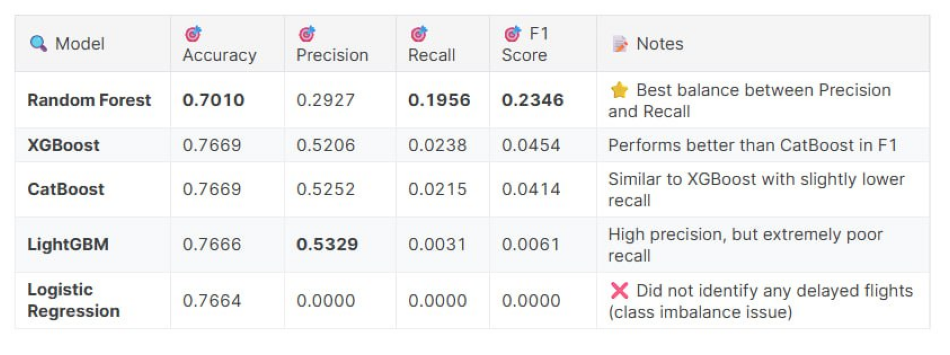

In [76]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load the image
img = mpimg.imread("image_flight_delay.jpg") 

# Display the image inside VS Code
plt.figure(figsize=(12,12))
plt.imshow(img)
plt.axis('off')  # optional: hide axes
plt.show()

On this project Dataset is imbalanced even occuracy is 0.8129 :  
82% on-time (On_Time = 0)  
18% delayed (Is_Delayed = 1) data  
When  I trained a model , it used to learn predict Non-Delayed samples. Thats why f1-score (0)=0.90 ,(1)=0.08  
I used   Downsampling method of Class balancing or handling Class Imbalance.  
Non-Delayed: 9000 → 1000  
Delayed: 1000  
we Downsampling method  so the model does not become biased toward the majority class.  

######Log Reg model (balanced datset) ######

In [ ]:
# original datasets are used for to create several models, make a copy to avoid modifying the original dataset
X_lr =X.copy()
y_lr= y.copy()
X_train, X_test, y_train, y_test = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42,stratify=y
)

Downsampling method of Class balancing or handling Class Imbalance.  
To avoid data leakage I splited dataset first, then down-sample only training data, the test set stays unseen.  

In [78]:
train_df = pd.concat([X_train, y_train], axis=1)
delayed = train_df[train_df["DELAY_15"] == 1]    #We randomly select the same number as delayed flights
ontime = train_df[train_df["DELAY_15"] == 0]    #Non-delayed flights are too many
ontime_sample = ontime.sample(n=len(delayed), random_state=42) # Take the same number of Non-Delayed samples as the number of Delayed samples.
balanced_train = pd.concat([delayed, ontime_sample])
balanced_train = balanced_train.sample(frac=1, random_state=42)  #Mix rows so the model does not see all delayed flights first

In [79]:
X_train_bal = balanced_train.drop("DELAY_15", axis=1)
y_train_bal = balanced_train["DELAY_15"]

| Dataset       | Encode?                  |
| ------------- | ------------------------ |
| `X_train_bal` | YES                      |
| `X_test`      | YES (using same encoder) |
| `y_train_bal` | NO                       |
| `y_test`      | NO                       |
target column already encoded    (On_Time = 0, Delayed = 1) 

In [ ]:
#  I did  the same steps to encode X_train_bal and X_test  as i did to create      Log Reg Model (not balanced datset)
numeric_cols = ["MONTH", "DAY", "DAY_OF_WEEK",
    "SCHEDULED_DEPARTURE", "SCHEDULED_ARRIVAL",
    "SCHEDULED_TIME", "DISTANCE",
    "TEMP_MAX_ORIGIN", "TEMP_MIN_ORIGIN", "PRECIP_ORIGIN",
    "TEMP_MAX_DEST", "TEMP_MIN_DEST", "PRECIP_DEST",
    "DEPARTURE_TIME" ]
target_encode_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "CITY", "STATE"]
onehot_cols = ["AIRLINE"]

preprocessor_lr = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("target_enc", TargetEncoder(), target_encode_cols),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False), onehot_cols)
])

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(max_iter=1000))
])



In [81]:

lr_pipeline.fit(X_train_bal, y_train_bal)

# Predict on test set
y_pred_lr = lr_pipeline.predict(X_test)

y_proba_lr=lr_pipeline.predict_proba(X_test)[:, 1].ravel()
# Evaluate

print("=== Logistic Regression (Balanced + Encoded) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression (Balanced + Encoded) ===
Accuracy: 0.6862100746027266
              precision    recall  f1-score   support

           0       0.90      0.69      0.78    865911
           1       0.34      0.68      0.45    200672

    accuracy                           0.69   1066583
   macro avg       0.62      0.68      0.62   1066583
weighted avg       0.80      0.69      0.72   1066583



Balancing the training data improved the model’s ability to detect delayed flights. Without balancing, the model mostly predicted on-time flights due to class imbalance.

--- Logistic Regression Confusion Matrix ---


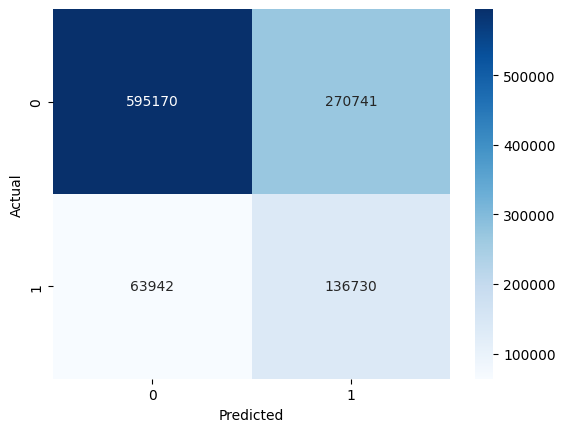

In [82]:
for name, y_pred in zip(
    ["Logistic Regression"],
    [y_pred_lr,]
):
    print(f"--- {name} Confusion Matrix ---")
    cm = confusion_matrix(y_test,y_pred_lr )
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

######Label encoding for XGBoost and Random Forest models ######  
XGBoost and Random Forest can handle imbalance using class weights, giving more importance to delayed flights and improving prediction of minority classes.

In [83]:
X_xgb_rf = X.copy()
y_xgb_rf= y.copy()
X_train, X_test, y_train, y_test = train_test_split(
    X_xgb_rf, y_xgb_rf, test_size=0.2, random_state=42,stratify=y
)

In [ ]:

label_encode_cols = ["AIRLINE", "DAY_OF_WEEK", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "CITY", "STATE"]

for col in label_encode_cols:
    le = LabelEncoder() # Categorical features were converted to numeric using LabelEncoder.
    X_train[col] = le.fit_transform(X_train[col]) # The encoder was fitted on training data.
    X_test[col] = le.transform(X_test[col]) #The encode applied to the test set to prevent data leakage.

######Random Forest ######

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0, 1])
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}



# Random Forest with class_weight

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    class_weight=class_weight_dict,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf=rf.predict_proba(X_test)[:, 1].ravel()
print("=== Random Forest with class_weight ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



=== Random Forest with class_weight ===
Accuracy: 0.7486721614726655
              precision    recall  f1-score   support

           0       0.92      0.75      0.83    865911
           1       0.41      0.72      0.52    200672

    accuracy                           0.75   1066583
   macro avg       0.66      0.74      0.67   1066583
weighted avg       0.82      0.75      0.77   1066583



--- RandomForest Confusion Matrix ---


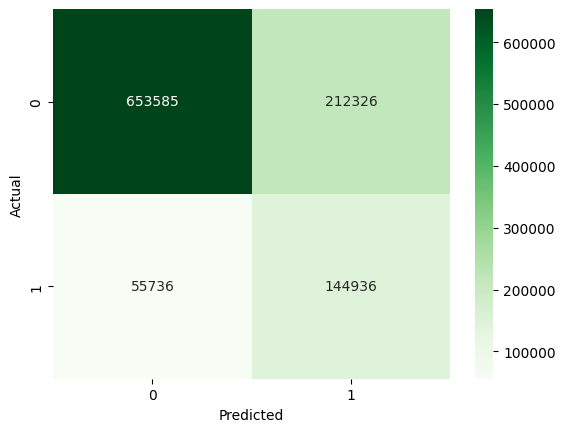

In [86]:
for name, y_pred in zip(
    ["RandomForest"],
    [y_pred_rf,]
):
    print(f"--- {name} Confusion Matrix ---")
    cm = confusion_matrix(y_test,y_pred_rf )
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

######XGBoost  ######

In [ ]:
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)

xb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

xb.fit(X_train, y_train)
y_pred_xgb = xb.predict(X_test)
y_proba_xgb=xb.predict_proba(X_test)[:, 1].ravel()
print("=== XGBoost with scale_pos_weight ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

=== XGBoost with scale_pos_weight ===
Accuracy: 0.9108330059639053
              precision    recall  f1-score   support

           0       0.96      0.93      0.94    865911
           1       0.74      0.81      0.77    200672

    accuracy                           0.91   1066583
   macro avg       0.85      0.87      0.86   1066583
weighted avg       0.91      0.91      0.91   1066583



--- XGBoost Confusion Matrix ---


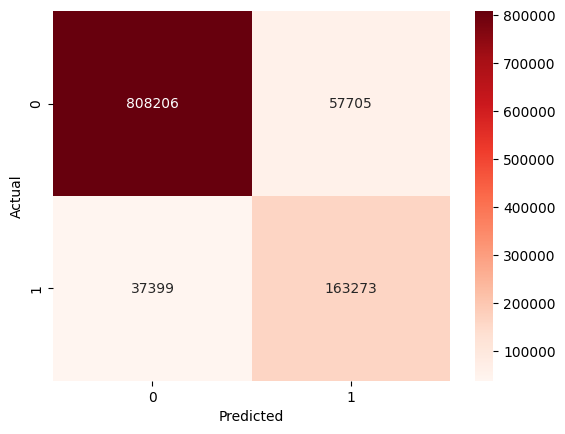

In [88]:
for name, y_pred in zip(
    ["XGBoost"],
    [y_pred_xgb,]
):
    print(f"--- {name} Confusion Matrix ---")
    cm = confusion_matrix(y_test,y_pred_xgb )
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Combining models

In [90]:
results = []

for name, y_pred in zip(
    ["Logistic Regression(Non balanced)","Logistic Regression", "Random Forest", "XGBoost"],
    [y_pred_log,y_pred_lr, y_pred_rf, y_pred_xgb]
):
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4)
    })


In [91]:
metrics_table = pd.DataFrame(results)
metrics_table

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression(Non balanced),0.8331,0.7975,0.1516,0.2547
1,Logistic Regression,0.6862,0.3356,0.6814,0.4497
2,Random Forest,0.7487,0.4057,0.7223,0.5195
3,XGBoost,0.9108,0.7389,0.8136,0.7744


Among all models tested, XGBoost performed best, accurately identifying delayed flights even in an imbalanced dataset

In [92]:
predictions_xgb = pd.DataFrame({
    "Flight Number": df_copy.loc[X_test.index, "FLIGHT_NUMBER"].values,
    "Delay Probability": y_proba_xgb
})

In [93]:
predictions_xgb["Delay Probability (%)"] = (predictions_xgb["Delay Probability"] * 100).round(2)

In [94]:
def assign_risk(p):
    if p >= 0.70:
        return "High"
    elif p >= 0.30:
        return "Medium"
    else:
        return "Low"

predictions_xgb["Risk Level"] = predictions_xgb["Delay Probability"].apply(assign_risk)

In [97]:
predictions_xgb = predictions_xgb[["Flight Number", "Delay Probability (%)", "Risk Level"]]
predictions_xgb = predictions_xgb.reset_index(drop=True)

print(predictions_xgb.head(10))

   Flight Number  Delay Probability (%) Risk Level
0           1357              13.190000        Low
1           1599              23.450001        Low
2           4491              15.000000        Low
3           3479              28.530001        Low
4           5608              20.940001        Low
5            760              22.670000        Low
6           2006              19.670000        Low
7           2784              14.900000        Low
8             82              14.700000        Low
9           1741              16.450001        Low


In [98]:
# Count number of flights per risk level
risk_counts = predictions_xgb["Risk Level"].value_counts()

print(risk_counts)

Risk Level
Low       729167
High      169496
Medium    167920
Name: count, dtype: int64


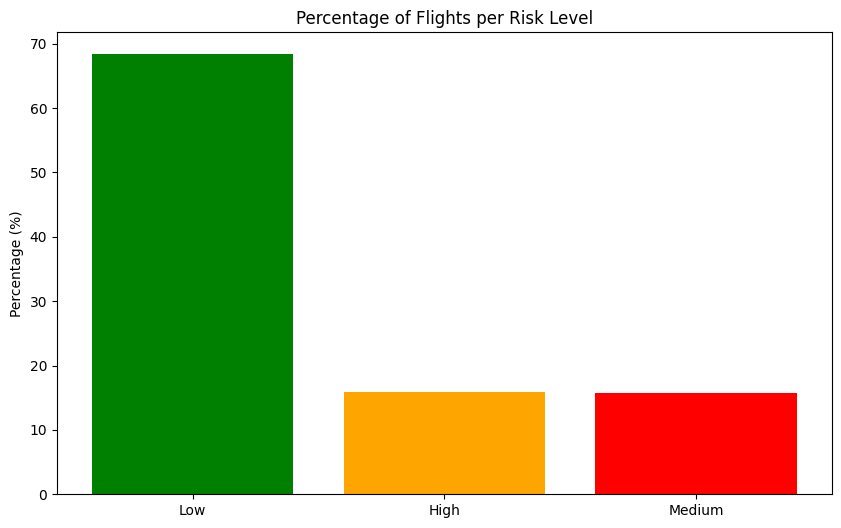

In [103]:
risk_percent = predictions_xgb["Risk Level"].value_counts(normalize=True) * 100

plt.figure(figsize=(10,6))
plt.bar(risk_percent.index, risk_percent.values, color=['green','orange','red'])
plt.title("Percentage of Flights per Risk Level")
plt.ylabel("Percentage (%)")
plt.show()

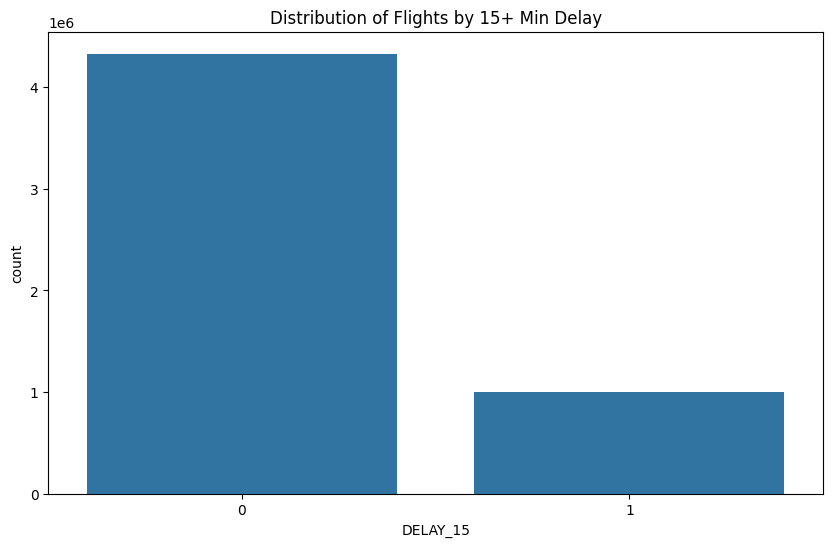

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.countplot(x='DELAY_15', data=df_copy)
plt.title("Distribution of Flights by 15+ Min Delay")

plt.show()